In [3]:
import platform
import sklearn

print(platform.system())
if platform.system() == 'Windows' :
    sklearn.set_config(display='text')

Windows


In [6]:
import matplotlib.pyplot as plt

#OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family ='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family ='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family ='NanumBarunGothic') # 리눅스

#마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

In [7]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, 
    n_features=10, 
    weights=[0.9, 0.1], 
    random_state=42
)

In [8]:
import pandas as pd

print(f'X.shape:{X.shape}')
print(pd.Series(y).value_counts())

X.shape:(1000, 10)
0    897
1    103
Name: count, dtype: int64


In [10]:
from imblearn.over_sampling import SMOTE
import numpy as np

# SMOTE 객체 생성
smote = SMOTE(random_state=42)

# 훈련 데이터에만 적용 (검증/테스트 데이터 적용 금지)
X_train_res, y_train_res = smote.fit_resample(X, y)

# 샘플링 후 클래스 비율 확인
print(np.bincount(y_train_res)) # 두 클래스의 개수가 같아짐

[897 897]


각 클래스별로 원하는 최종 샘플 수 지정 target_dict = {0:1000, 1:1000}

In [12]:
from imblearn.over_sampling import SMOTE
import numpy as np

# 각 클래스별로 원하는 최종 샘플 수 지정 (예: 각 200개씩)
target_dict = {0: 1000, 1:1000}

smote = SMOTE(sampling_strategy=target_dict, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X, y)

print(np.bincount(y_train_res))
# 출력 결과: [200 200 200]

[1000 1000]


기존 데이터 수 기반 배수 증량 방식

In [13]:
# 기존 최대 클래스 개수(51개)의 3배(153개)로 증량
multiplier = 3
max_count = np.max(np.bincount(y))
target_dict = {label: max_count * multiplier for label in np.unique(y)}

smote = SMOTE(sampling_strategy=target_dict, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X, y)

print(np.bincount(y_train_res))
# 출력 결과: [153 153 153]

[2691 2691]


In [17]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek

# 1. 불균형 데이터셋 생성 (샘플 2000개, 소수 클래스 비율 약 10%)
X, y = make_classification(
    n_samples=2000, n_features=20, n_informative=10,
    n_clusters_per_class=1, weights=[0.9, 0.1], random_state=42
)

# Train / Test 분할 (stratify로 데이터 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 2. 비교할 샘플링 기법 정의
samplers = {
    'Baseline (No Sampling)': None,
    'SMOTE': SMOTE(random_state=42),
    'Borderline-SMOTE': BorderlineSMOTE(random_state=42),
    'SMOTE-Tomek': SMOTETomek(random_state=42)
}

# 3. 샘플링 적용, 모델 학습 및 성과 비교
results = []

for name, sampler in samplers.items():
    if sampler is not None:
        # Data Leakage 방지를 위해 훈련 데이터에만 샘플링 적용
        X_res, y_res = sampler.fit_resample(X, y)
    else:
        X_res, y_res = X, y
    
    # 모델 학습
    model = RandomForestClassifier(random_state=42)
    model.fit(X_res, y_res)
    
    # 예측
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # 지표 계산 (소수 클래스 기준)
    results.append({
        'Technique': name,
        'Train Size': len(y_res),
        'Class 1 Count': np.sum(y_res == 1),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
    })

# 4. 결과 비교 테이블 출력
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

             Technique  Train Size  Class 1 Count  Recall  Precision  F1-Score  ROC-AUC
Baseline (No Sampling)        2000            212     1.0        1.0       1.0      1.0
                 SMOTE        3576           1788     1.0        1.0       1.0      1.0
      Borderline-SMOTE        3576           1788     1.0        1.0       1.0      1.0
           SMOTE-Tomek        3576           1788     1.0        1.0       1.0      1.0


시각화하는 코드

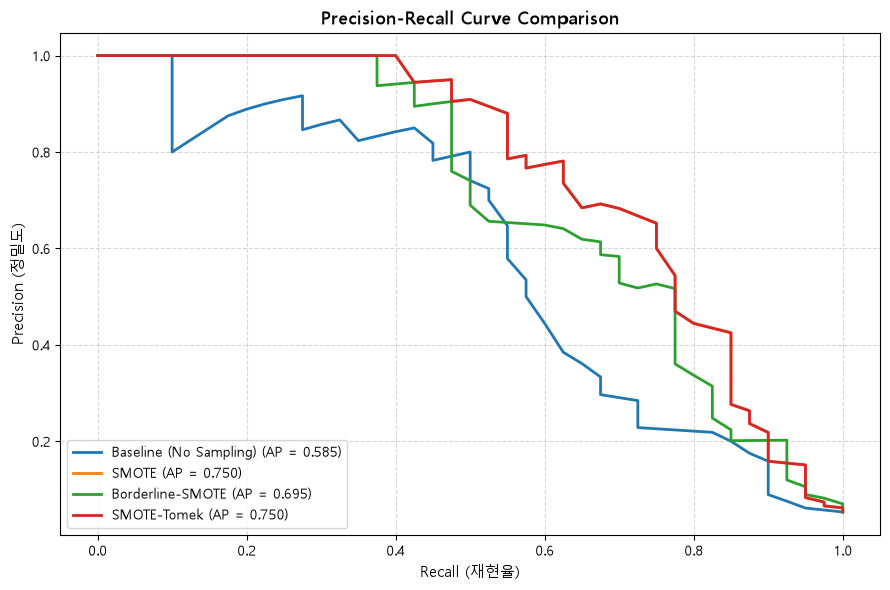

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek

# 1. 극단적인 불균형 데이터셋 생성 (소수 클래스 약 5%)
X, y = make_classification(
    n_samples=2500, n_features=20, n_informative=10,
    weights=[0.95, 0.05], random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 2. 샘플러 정의
samplers = {
    'Baseline (No Sampling)': None,
    'SMOTE': SMOTE(random_state=42),
    'Borderline-SMOTE': BorderlineSMOTE(random_state=42),
    'SMOTE-Tomek': SMOTETomek(random_state=42)
}

# 3. 시각화 설정
plt.figure(figsize=(9, 6))

for name, sampler in samplers.items():
    if sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train, y_train)
    else:
        X_res, y_res = X_train, y_train
    
    # 모델 학습 및 소수 클래스(1) 확률 예측
    model = RandomForestClassifier(random_state=42)
    model.fit(X_res, y_res)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Precision, Recall 및 Average Precision(AP) 계산
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap_score = average_precision_score(y_test, y_prob)
    
    # PR 곡선 출력
    plt.plot(recall, precision, lw=2, label=f'{name} (AP = {ap_score:.3f})')

# 4. 그래프 스타일 지정
plt.xlabel('Recall (재현율)', fontsize=11)
plt.ylabel('Precision (정밀도)', fontsize=11)
plt.title('Precision-Recall Curve Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()